In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("bank.csv")

In [3]:
df.columns = df.columns.str.strip()

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

Dataset Shape: (11162, 17)

Columns:
 Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [5]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.0+ MB
None


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [7]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1528.538524     15.658036    371.993818      2.508421   
std       11.913369   3225.413326      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    122.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1708.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       20.7

In [8]:
df["deposit"] = df["deposit"].map({"yes": 1, "no": 0})

In [9]:
print("\nTarget Value Counts:")
print(df["deposit"].value_counts())


Target Value Counts:
deposit
0    5873
1    5289
Name: count, dtype: int64


In [10]:
total_customers = len(df)
subscribed = df["deposit"].sum()
not_subscribed = total_customers - subscribed
conversion_rate = df["deposit"].mean() * 100

In [11]:
print("\n===== FUNNEL METRICS =====")
print("Total Customers:", total_customers)
print("Subscribed:", subscribed)
print("Not Subscribed:", not_subscribed)
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")


===== FUNNEL METRICS =====
Total Customers: 11162
Subscribed: 5289
Not Subscribed: 5873
Overall Conversion Rate: 47.38%


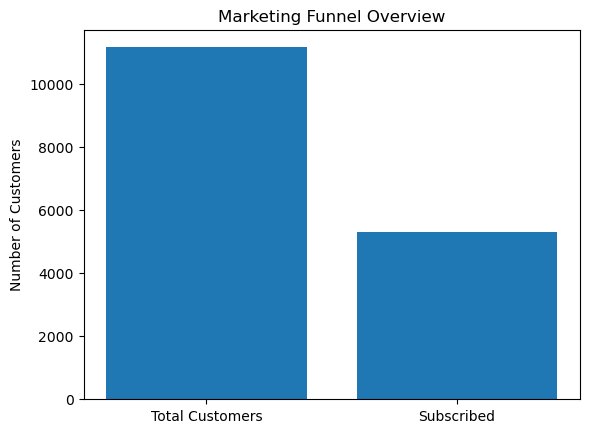

In [12]:
plt.figure()
plt.bar(["Total Customers", "Subscribed"],
        [total_customers, subscribed])
plt.title("Marketing Funnel Overview")
plt.ylabel("Number of Customers")
plt.show()

In [13]:
contact_analysis = df.groupby("contact")["deposit"].mean().sort_values(ascending=False)


In [14]:
print("\n===== Conversion Rate by Contact Type =====")
print(contact_analysis)


===== Conversion Rate by Contact Type =====
contact
cellular     0.543273
telephone    0.503876
unknown      0.225916
Name: deposit, dtype: float64


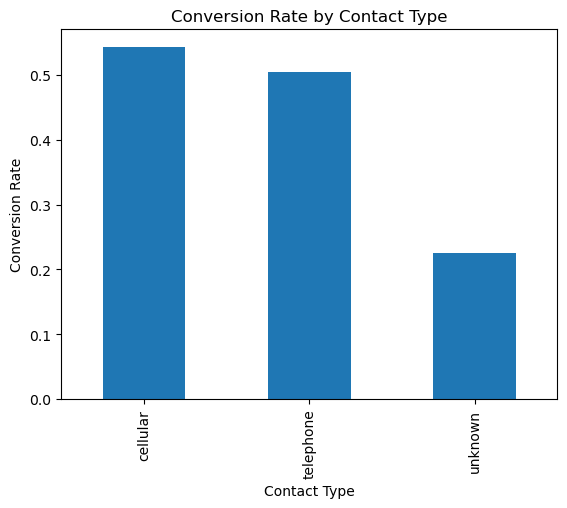

In [15]:
plt.figure()
contact_analysis.plot(kind="bar")
plt.title("Conversion Rate by Contact Type")
plt.ylabel("Conversion Rate")
plt.xlabel("Contact Type")
plt.show()

In [16]:

campaign_analysis = df.groupby("campaign")["deposit"].mean()

In [17]:
print("\n===== Conversion Rate by Number of Contacts =====")
print(campaign_analysis.head(10))


===== Conversion Rate by Number of Contacts =====
campaign
1     0.533764
2     0.462682
3     0.467827
4     0.411154
5     0.367725
6     0.347170
7     0.338129
8     0.250000
9     0.291667
10    0.269231
Name: deposit, dtype: float64


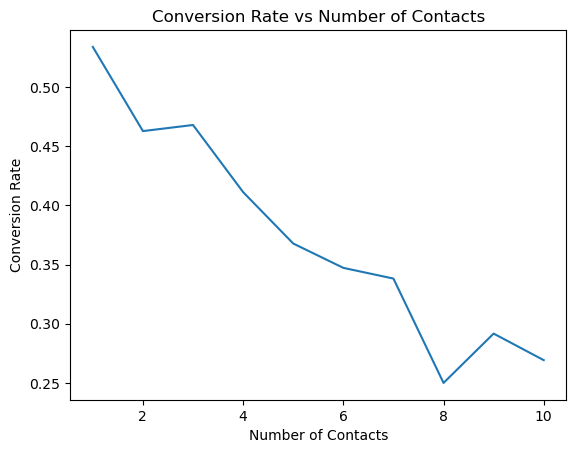

In [18]:
plt.figure()
campaign_analysis.head(10).plot()
plt.title("Conversion Rate vs Number of Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Conversion Rate")
plt.show()

In [19]:
job_analysis = df.groupby("job")["deposit"].mean().sort_values(ascending=False)


In [20]:
print("\n===== Conversion Rate by Job =====")
print(job_analysis)


===== Conversion Rate by Job =====
job
student          0.747222
retired          0.663239
unemployed       0.565826
management       0.507015
unknown          0.485714
admin.           0.473013
self-employed    0.461728
technician       0.460779
services         0.399783
housemaid        0.397810
entrepreneur     0.375000
blue-collar      0.364198
Name: deposit, dtype: float64


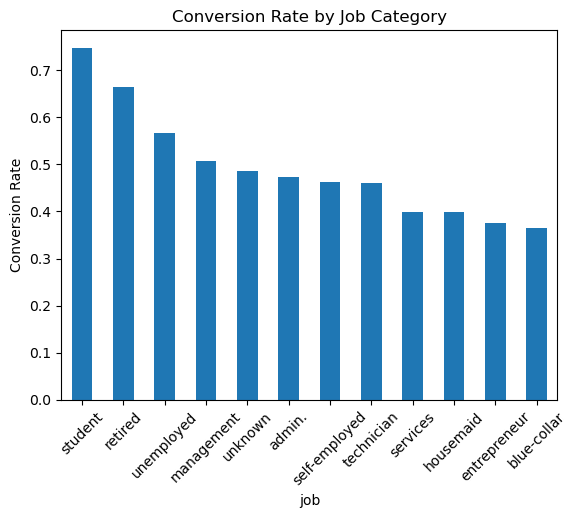

In [21]:
plt.figure()
job_analysis.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Conversion Rate by Job Category")
plt.ylabel("Conversion Rate")
plt.show()


In [22]:
age_analysis = df.groupby("deposit")["age"].mean()

In [23]:
print("\n===== Average Age by Subscription =====")
print(age_analysis)


===== Average Age by Subscription =====
deposit
0    40.837391
1    41.670070
Name: age, dtype: float64


In [24]:
df.to_csv("cleaned_bank.csv", index=False)

In [25]:
print("\nAnalysis Completed Successfully")


Analysis Completed Successfully
